# Interactive Pentagon Structure Manipulation GUI

**Features:**
- Manual adjustment of 5-petal 3×3 lattice structure with decay profiles
- Real-time stretching/contracting of edges and corners
- MEEP electromagnetic simulation integration
- Matrix transformation export/import capabilities

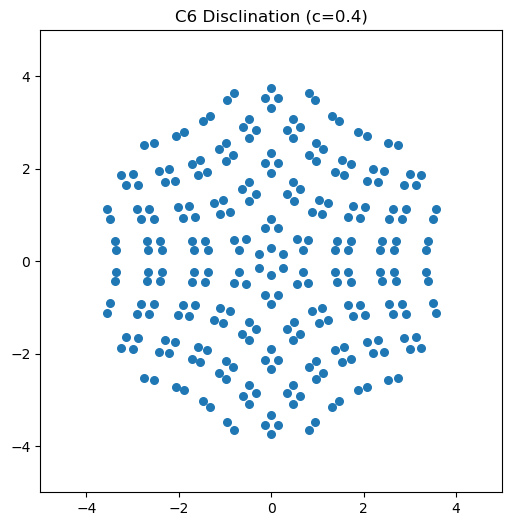

In [ ]:
# ==========================================
# CELL 1: Proper Volterra C4 → Cn (No Gap)
# ==========================================

import meep as mp
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARAMETERS
# -----------------------------
a = 1.0
r_hole = 0.27 * a
offset = 0.35 * a
eps_bg = 3.42**2
pml_layers = [mp.PML(1.0)]
resolution = 50

Rmax = 3
cavity_radius = 4.0
cell_size = 10

n = 6       # target symmetry
c = 0.4     # core pull

# -----------------------------
# C4 basis
# -----------------------------
c4_basis = [
    (+offset, +offset),
    (+offset, -offset),
    (-offset, +offset),
    (-offset, -offset),
]

# -----------------------------
# Build base C4 lattice
# -----------------------------
base_points = []

for i in range(-Rmax, Rmax+1):
    for j in range(-Rmax, Rmax+1):
        for dx, dy in c4_basis:
            x = i*a + dx
            y = j*a + dy
            r = np.sqrt(x**2 + y**2)
            if r < cavity_radius:
                base_points.append((x, y))

base_points = np.array(base_points)

# -----------------------------
# Step 1: Lift angular domain
# -----------------------------
extended_points = []

theta_extension_factor = n / 4   # how much to extend angular range

for x, y in base_points:

    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)

    # create copies covering extended angular domain
    for k in range(int(np.ceil(theta_extension_factor))):
        theta_ext = theta + 2*np.pi*k
        if theta_ext < 2*np.pi * theta_extension_factor:
            extended_points.append((r, theta_ext))

# -----------------------------
# Step 2: Compress back to 2π
# θ' = (4/n) θ
# -----------------------------
coords = []

alpha = 4 / n

for r, theta in extended_points:
    theta_new = alpha * theta
    x_new = r*np.cos(theta_new)
    y_new = r*np.sin(theta_new)
    if r < cavity_radius:
        coords.append((x_new, y_new))

coords = np.array(coords)

# Remove duplicates
coords = np.unique(np.round(coords, 6), axis=0)

# -----------------------------
# Core Pull (n nearest holes)
# -----------------------------
if coords.shape[0] >= n:

    distances = np.linalg.norm(coords, axis=1)
    nearest_indices = np.argsort(distances)[:n]

    for idx in nearest_indices:
        r = distances[idx]
        theta = np.arctan2(coords[idx,1], coords[idx,0])
        r_new = (1 - c) * r
        coords[idx,0] = r_new*np.cos(theta)
        coords[idx,1] = r_new*np.sin(theta)

# -----------------------------
# Convert to Meep geometry
# -----------------------------
geometry_cN = [
    mp.Cylinder(
        r_hole,
        height=mp.inf,
        center=mp.Vector3(x, y),
        material=mp.Medium(epsilon=1),
    )
    for (x, y) in coords
]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6,6))
plt.scatter(coords[:,0], coords[:,1], s=30)
plt.gca().set_aspect("equal")
plt.title(f"C{n} Disclination (c={c})")
plt.xlim(-cell_size/2, cell_size/2)
plt.ylim(-cell_size/2, cell_size/2)
plt.show()

In [ ]:
# ==========================================
# CELL 2: Harminv Resonance Extraction
# ==========================================

sim = mp.Simulation(
    cell_size=mp.Vector3(cell_size, cell_size),
    geometry=geometry_cN,
    boundary_layers=pml_layers,
    resolution=resolution,
    default_material=mp.Medium(epsilon=eps_bg)
)

fcen = 0.25
df = 0.4

sim.sources = [
    mp.Source(
        mp.GaussianSource(fcen, fwidth=df),
        component=mp.Hz,
        center=mp.Vector3(0.2,0.0)
    )
]

harminv = mp.Harminv(mp.Hz, mp.Vector3(0.2,0.0), fcen, df)

sim.run(mp.after_sources(harminv), until=600)

if len(harminv.modes) == 0:
    raise RuntimeError("No resonant modes detected. Increase runtime or cavity size.")

resonant_freqs = [m.freq for m in harminv.modes]

print("Resonant Modes:")
for m in harminv.modes:
    print(f"freq={m.freq:.6f}, Q={m.Q:.2f}")

-----------
Initializing structure...
time for choose_chunkdivision = 0.00279713 s
Working in 2D dimensions.
Computational cell is 10 x 10 x 0 with resolution 50
     cylinder, center = (-3.56183,-1.12176,0)
          radius 0.27, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-3.56183,1.12176,0)
          radius 0.27, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-3.49464,-0.912401,0)
          radius 0.27, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-3.49464,0.912401,0)
          radius 0.27, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-3.38466,-0.434812,0)
          radius 0.27, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-3.38466,0.434812,0)
          radius

In [ ]:
# ==========================================
# CELL 3: Dominant Hz Mode
# ==========================================

dominant_freq = resonant_freqs[0]

sim = mp.Simulation(
    cell_size=mp.Vector3(cell_size, cell_size),
    geometry=geometry_cN,
    boundary_layers=pml_layers,
    resolution=resolution,
    default_material=mp.Medium(epsilon=eps_bg)
)

sim.sources = [
    mp.Source(
        mp.ContinuousSource(frequency=dominant_freq),
        component=mp.Hz,
        center=mp.Vector3(0.2,0.0)
    )
]

sim.run(until=300)

hz = sim.get_array(
    center=mp.Vector3(),
    size=mp.Vector3(cell_size, cell_size),
    component=mp.Hz
)

plt.figure(figsize=(6,6))
plt.imshow(hz.T, origin="lower",
           extent=[-cell_size/2, cell_size/2,
                   -cell_size/2, cell_size/2],
           cmap="RdBu")
plt.colorbar(label="Hz")
plt.title("Dominant Eigenmode")
plt.show()

-----------
Initializing structure...
time for choose_chunkdivision = 0.0032928 s
Working in 2D dimensions.
Computational cell is 10 x 10 x 0 with resolution 50
     cylinder, center = (-3.56183,-1.12176,0)
          radius 0.27, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-3.56183,1.12176,0)
          radius 0.27, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-3.49464,-0.912401,0)
          radius 0.27, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-3.49464,0.912401,0)
          radius 0.27, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-3.38466,-0.434812,0)
          radius 0.27, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (-3.38466,0.434812,0)
          radius 

KeyboardInterrupt: 

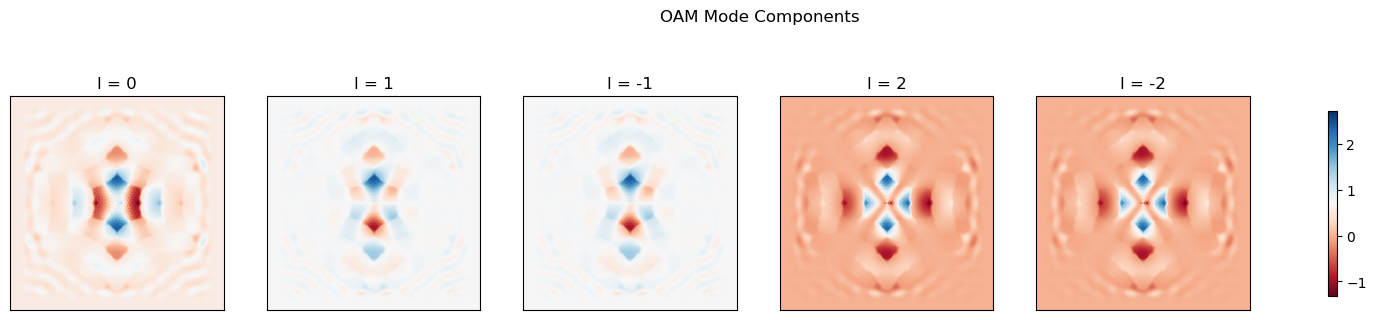

In [ ]:
# ==========================================
# CELL 4: OAM Mode Decomposition
# ==========================================

Nx = hz.shape[0]
x = np.linspace(-cell_size/2, cell_size/2, Nx)
y = np.linspace(-cell_size/2, cell_size/2, Nx)
X, Y = np.meshgrid(x, y)
Theta = np.arctan2(Y, X)

l_values = [0, 1, -1, 2, -2]

fig, axes = plt.subplots(1,5, figsize=(20,4))

for ax, l in zip(axes, l_values):
    hz_l = np.real(hz * np.exp(-1j*l*Theta))
    im = ax.imshow(hz_l.T,
                   origin="lower",
                   extent=[-cell_size/2, cell_size/2,
                           -cell_size/2, cell_size/2],
                   cmap="RdBu")
    ax.set_title(f"l = {l}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
plt.suptitle("OAM Mode Components")
plt.show()